In [1]:
import pandas as pd

In [2]:
url="https://raw.githubusercontent.com/JoelRomero123/PARCIAL4-JOEL-ROMERO-2523552017/refs/heads/main/clave_H_correlacion.csv"
df=pd.read_csv(url)
 #Mostrar las primeras filas del dataset y explicar su estructura.
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          256 non-null    object 
 1   edad                256 non-null    int64  
 2   ingresos_mensuales  256 non-null    int64  
 3   frecuencia_compra   256 non-null    int64  
 4   ticket_promedio     255 non-null    float64
 5   satisfaccion        255 non-null    float64
 6   reclamos            256 non-null    int64  
 7   uso_app             256 non-null    int64  
 8   tiempo_respuesta    255 non-null    float64
 9   consumo_total       256 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 20.1+ KB


In [3]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
for col in numerical_cols:
    print(f"- {col}")

Numerical columns:
- edad
- ingresos_mensuales
- frecuencia_compra
- ticket_promedio
- satisfaccion
- reclamos
- uso_app
- tiempo_respuesta
- consumo_total


In [4]:
#Identificar las variables numéricas del dataset.
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64


Checking for outliers using box plots:


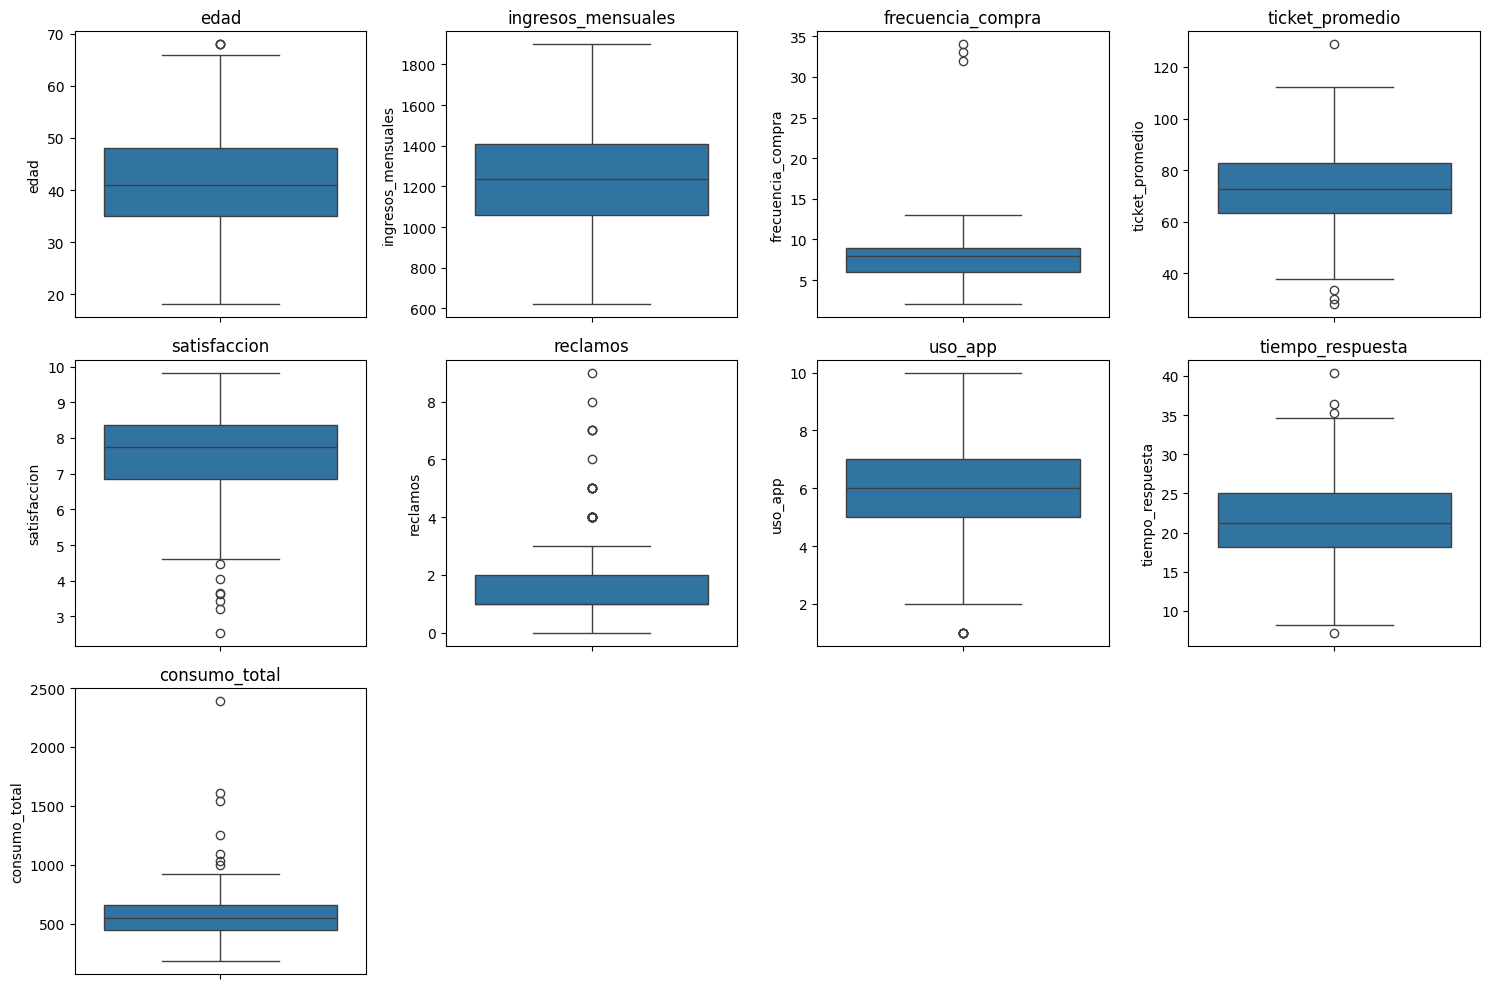

In [5]:
#Revisar datos nulos, valores atípicos y consistencia general.
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Checking for outliers using box plots:")

# Plotting box plots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [6]:
print("Descriptive statistics for numerical columns:")
print(df[numerical_cols].describe())

Descriptive statistics for numerical columns:
             edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
count  256.000000          256.000000         256.000000        255.00000   
mean    41.816406         1238.472656           8.070312         72.85400   
std     10.051704          248.618408           3.430391         14.43644   
min     18.000000          619.000000           2.000000         27.97000   
25%     35.000000         1059.250000           6.000000         63.32500   
50%     41.000000         1236.500000           8.000000         72.72000   
75%     48.000000         1407.250000           9.000000         82.97500   
max     68.000000         1899.000000          34.000000        128.77000   

       satisfaccion    reclamos     uso_app  tiempo_respuesta  consumo_total  
count    255.000000  256.000000  256.000000        255.000000     256.000000  
mean       7.560667    1.550781    5.871094         21.359843     569.450977  
std        1.262785    

In [7]:
print("Rows with missing values:")
display(df[df.isnull().any(axis=1)])

Rows with missing values:


,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
10,H-C0011,43,1457,7,79.97,NaN,1,5,13.14,587.95
20,H-C0021,48,1256,6,87.09,7.54,1,3,NaN,555.62
30,H-C0031,68,1204,6,NaN,7.81,1,4,25.92,414.68


In [8]:
#Calcular la matriz de correlación
print("Correlation Matrix:")
correlation_matrix = df[numerical_cols].corr()
display(correlation_matrix)

Correlation Matrix:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.016661,-0.000307,0.150597,0.008511,0.027201,0.116954,-0.063155,0.067152
ingresos_mensuales,0.016661,1.000000,0.051051,0.568912,-0.014222,0.054986,-0.068167,-0.041842,0.292867
frecuencia_compra,-0.000307,0.051051,1.000000,0.038058,0.152668,-0.111787,0.439858,-0.216890,0.879637
ticket_promedio,0.150597,0.568912,0.038058,1.000000,0.056423,-0.039127,-0.026956,-0.038734,0.430907
satisfaccion,0.008511,-0.014222,0.152668,0.056423,1.000000,-0.799622,0.178477,-0.542621,0.262528
reclamos,0.027201,0.054986,-0.111787,-0.039127,-0.799622,1.000000,0.012984,0.473224,-0.211259
uso_app,0.116954,-0.068167,0.439858,-0.026956,0.178477,0.012984,1.000000,-0.324614,0.458099
tiempo_respuesta,-0.063155,-0.041842,-0.216890,-0.038734,-0.542621,0.473224,-0.324614,1.000000,-0.308279
consumo_total,0.067152,0.292867,0.879637,0.430907,0.262528,-0.211259,0.458099,-0.308279,1.000000


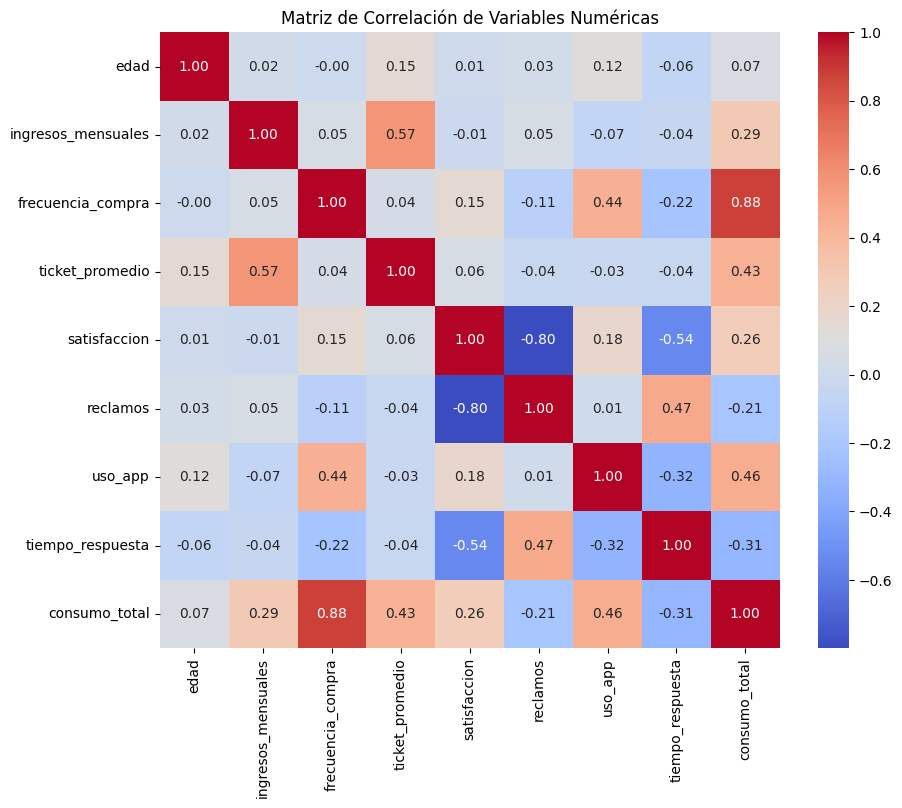

In [10]:
#MATRIZ DE CORRELACION
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [12]:
# Desapilar la matriz de correlación para obtener pares de variables y sus correlaciones
correlation_pairs = correlation_matrix.unstack()

# Filtrar las correlaciones positivas y eliminar las autocorrelaciones
high_positive_correlations_filtered = correlation_pairs[(correlation_pairs > 0) & (correlation_pairs < 1)]

# Crear una lista para almacenar entradas de correlación únicas
unique_correlations_data = []
seen_pairs = set()

for (var1, var2), value in high_positive_correlations_filtered.items():
    # Normalizar el par para tratar (A,B) y (B,A) como lo mismo
    normalized_pair = tuple(sorted((var1, var2)))

    if normalized_pair not in seen_pairs:
        seen_pairs.add(normalized_pair)
        unique_correlations_data.append(((var1, var2), value))

# Convertir la lista de tuplas (índice, valor) en una Serie
# Primero, extraer índices y valores
if unique_correlations_data:
    indices = [item[0] for item in unique_correlations_data]
    values = [item[1] for item in unique_correlations_data]

    # Crear un MultiIndex para la Serie
    multi_index = pd.MultiIndex.from_tuples(indices, names=['Variable1', 'Variable2'])

    unique_positive_correlations = pd.Series(values, index=multi_index)
    unique_positive_correlations = unique_positive_correlations.sort_values(ascending=False)
else:
    unique_positive_correlations = pd.Series(dtype='float64')


print("Principales correlaciones positivas (excluyendo autocorrelaciones y duplicados):")
display(unique_positive_correlations.head(10)) # Mostrar las 10 primeras para mayor brevedad

Principales correlaciones positivas (excluyendo autocorrelaciones y duplicados):


Variable1           Variable2       
frecuencia_compra   consumo_total       0.879637
ingresos_mensuales  ticket_promedio     0.568912
reclamos            tiempo_respuesta    0.473224
uso_app             consumo_total       0.458099
frecuencia_compra   uso_app             0.439858
ticket_promedio     consumo_total       0.430907
ingresos_mensuales  consumo_total       0.292867
satisfaccion        consumo_total       0.262528
                    uso_app             0.178477
frecuencia_compra   satisfaccion        0.152668
dtype: float64

In [13]:
# Desapilar la matriz de correlación para obtener pares de variables y sus correlaciones
correlation_pairs = correlation_matrix.unstack()

# Filtrar las correlaciones negativas y eliminar las autocorrelaciones
high_negative_correlations_filtered = correlation_pairs[(correlation_pairs < 0)]

# Crear una lista para almacenar entradas de correlación únicas
unique_negative_correlations_data = []
seen_pairs_negative = set()

for (var1, var2), value in high_negative_correlations_filtered.items():
    # Normalizar el par para tratar (A,B) y (B,A) como lo mismo
    normalized_pair = tuple(sorted((var1, var2)))

    if normalized_pair not in seen_pairs_negative:
        seen_pairs_negative.add(normalized_pair)
        unique_negative_correlations_data.append(((var1, var2), value))

# Convertir la lista de tuplas (índice, valor) en una Serie
# Primero, extraer índices y valores
if unique_negative_correlations_data:
    indices_negative = [item[0] for item in unique_negative_correlations_data]
    values_negative = [item[1] for item in unique_negative_correlations_data]

    # Crear un MultiIndex para la Serie
    multi_index_negative = pd.MultiIndex.from_tuples(indices_negative, names=['Variable1', 'Variable2'])

    unique_negative_correlations = pd.Series(values_negative, index=multi_index_negative)
    # Ordenar por el valor de correlación (descendente) para obtener las más negativas primero
    unique_negative_correlations = unique_negative_correlations.sort_values(ascending=True)
else:
    unique_negative_correlations = pd.Series(dtype='float64')


print("Principales correlaciones negativas (excluyendo autocorrelaciones y duplicados):")
display(unique_negative_correlations.head(10)) # Mostrar las 10 primeras para mayor brevedad

Principales correlaciones negativas (excluyendo autocorrelaciones y duplicados):


Variable1           Variable2       
satisfaccion        reclamos           -0.799622
                    tiempo_respuesta   -0.542621
uso_app             tiempo_respuesta   -0.324614
tiempo_respuesta    consumo_total      -0.308279
frecuencia_compra   tiempo_respuesta   -0.216890
reclamos            consumo_total      -0.211259
frecuencia_compra   reclamos           -0.111787
ingresos_mensuales  uso_app            -0.068167
edad                tiempo_respuesta   -0.063155
ingresos_mensuales  tiempo_respuesta   -0.041842
dtype: float64

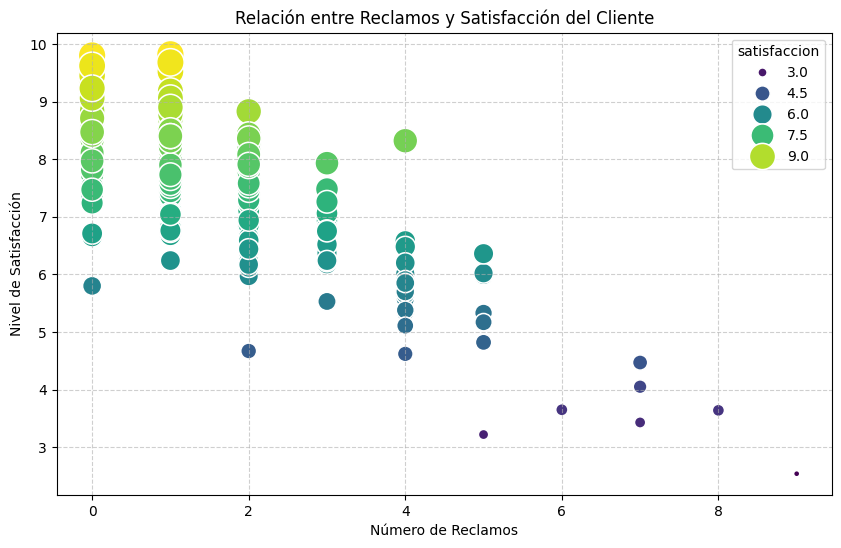

In [17]:
#Generar un gráfico de dispersión para visualizar la relación entre reclamos y satisfacción
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='reclamos', y='satisfaccion', data=df, hue='satisfaccion', palette='viridis', size='satisfaccion', sizes=(20, 400))
plt.title('Relación entre Reclamos y Satisfacción del Cliente')
plt.xlabel('Número de Reclamos')
plt.ylabel('Nivel de Satisfacción')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
# Calcular la correlación específica entre 'tiempo_respuesta' y 'satisfaccion'
correlation_tiempo_satisfaccion = df['tiempo_respuesta'].corr(df['satisfaccion'])
print(f"Correlación entre Tiempo de Respuesta y Satisfacción: {correlation_tiempo_satisfaccion:.2f}")

Correlación entre Tiempo de Respuesta y Satisfacción: -0.54


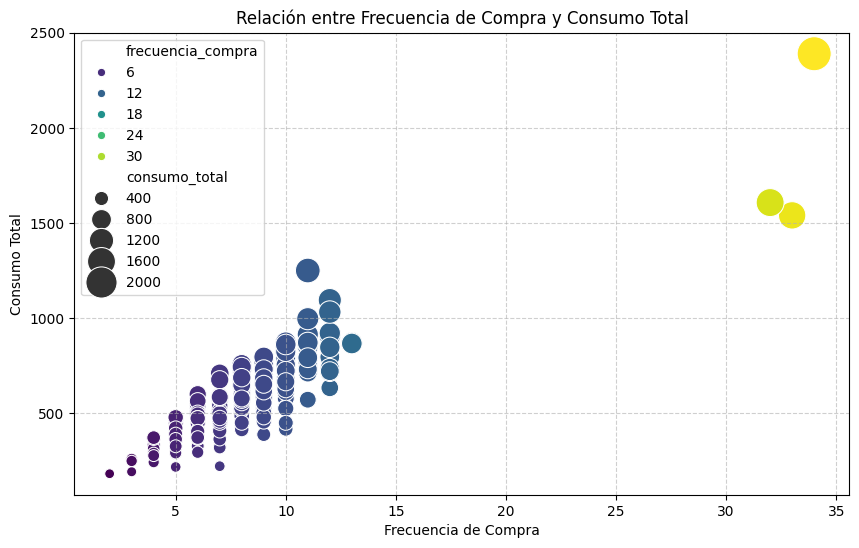

In [19]:
#visualizar la relación entre 'frecuencia_compra' y 'consumo_total'
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='frecuencia_compra', y='consumo_total', data=df, hue='frecuencia_compra', palette='viridis', size='consumo_total', sizes=(50, 600))
plt.title('Relación entre Frecuencia de Compra y Consumo Total')
plt.xlabel('Frecuencia de Compra')
plt.ylabel('Consumo Total')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

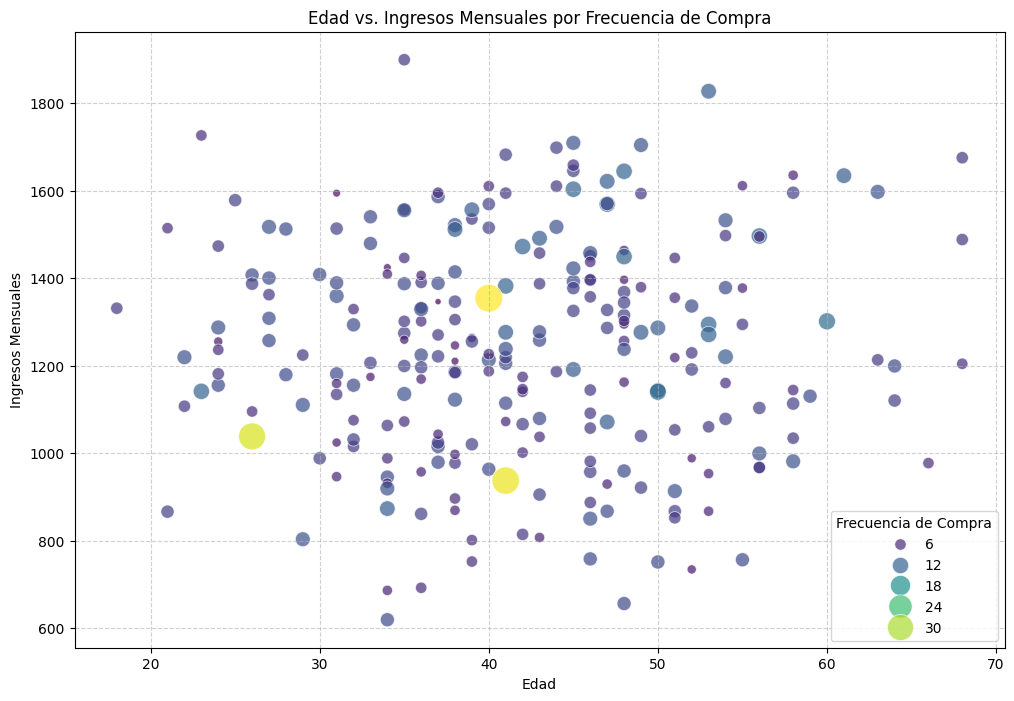

In [20]:
#EDAD VS INGRESOS MENSUALES POR FRECUENCIA DE COMPRA
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='edad', y='ingresos_mensuales', hue='frecuencia_compra', data=df, palette='viridis', size='frecuencia_compra', sizes=(20, 400), alpha=0.7)
plt.title('Edad vs. Ingresos Mensuales por Frecuencia de Compra')
plt.xlabel('Edad')
plt.ylabel('Ingresos Mensuales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Frecuencia de Compra')
plt.show()